# Task 03 — Feature Engineering Mastery

**Author:** Mussa Khan (@musagithub1)

This notebook demonstrates feature creation, target encoding, binning, polynomial/interaction features, Mutual Information, RFE, L1 selection, feature importance, and baseline-vs-final evaluation on a 5,000-row synthetic employee attrition dataset.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_dataset, clean_target
from src.preprocessing import add_domain_features, build_preprocessor, fit_target_encoding, apply_target_encoding
from src.modeling import evaluate_classifier, select_features, fit_feature_importance

RANDOM_SEED = 42
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
DATA_PATH = ROOT / "data" / "employee_attrition_feature_engineering_5000.csv"
print("Setup complete")

Setup complete


## 1. Load and inspect the dataset

In [2]:
df = clean_target(load_dataset(DATA_PATH))
print("Shape:", df.shape)
df.head()

Shape: (5000, 28)


,Age,Gender,Department,JobRole,EducationLevel,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,YearsSincePromotion,YearsWithManager,TotalWorkingYears,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,PerformanceRating,TrainingHours,Overtime,BusinessTravel,NumCompaniesWorked,SalaryHikePercent,StockOptionLevel,Promotions,RemoteWork,Dependents,JobLevel,CompanySize,Attrition
0,24,Male,IT,Specialist,Bachelor,7825.0,4,4,0,2.0,11,16.0,4.0,4,3,3,47.0,No,Rarely,3,11,3,0,No,2,Mid,Medium,0
1,51,Female,Marketing,Analyst,PhD,12587.0,10,3,2,5.0,12,16.0,3.0,2,1,3,46.0,No,Frequently,1,15,3,3,No,0,Mid,Large,0
2,47,Female,Engineering,Engineer,High School,8395.0,4,2,3,4.0,5,21.0,2.0,3,4,2,62.0,No,Frequently,2,19,3,1,No,0,Mid,Large,0
3,38,Female,IT,Coordinator,Bachelor,7177.0,7,1,6,3.0,10,13.0,3.0,2,2,4,19.0,No,Sometimes,1,11,2,2,No,3,Entry,Large,0
4,38,Male,HR,Executive,Bachelor,NaN,4,3,4,4.0,5,9.0,2.0,4,2,3,41.0,Yes,Rarely,4,11,2,0,No,4,Mid,Medium,0


In [3]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Department               5000 non-null   object 
 3   JobRole                  5000 non-null   object 
 4   EducationLevel           5000 non-null   object 
 5   MonthlyIncome            4900 non-null   float64
 6   YearsAtCompany           5000 non-null   int64  
 7   YearsInCurrentRole       5000 non-null   int64  
 8   YearsSincePromotion      5000 non-null   int64  
 9   YearsWithManager         4900 non-null   float64
 10  TotalWorkingYears        5000 non-null   int64  
 11  DistanceFromHome         4900 non-null   float64
 12  JobSatisfaction          4900 non-null   float64
 13  EnvironmentSatisfaction  5000 non-null   int64  
 14  WorkLifeBalance         

Attrition
0    3801
1    1199
Name: count, dtype: int64
Attrition
Stayed    3801
Left      1199
Name: count, dtype: int64


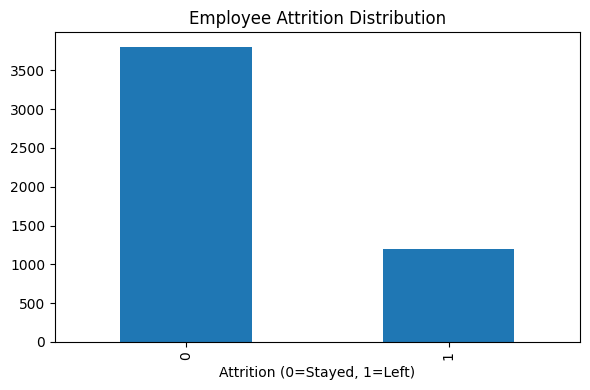

In [4]:
target_counts = df["Attrition"].value_counts()
print(target_counts)
print(target_counts.rename(index={0: "Stayed", 1: "Left"}))

plt.figure(figsize=(6, 4))
target_counts.sort_index().plot(kind="bar")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition (0=Stayed, 1=Left)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_attrition_distribution.png", dpi=150)
plt.show()

## 2. Train/test split — before target encoding

In [5]:
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
print(X_train.shape, X_test.shape)

(4000, 27) (1000, 27)


## 3. Baseline model

In [6]:
numeric_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(include="object").columns

baseline_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

baseline_model = Pipeline([
    ("preprocessor", baseline_preprocessor),
    ("model", LogisticRegression(max_iter=3000)),
])
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_classifier(y_test, baseline_pred, baseline_prob)
pd.Series(baseline_metrics, name="Baseline")

/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy     0.777000
Precision    0.593407
Recall       0.225000
F1           0.326284
ROC-AUC      0.739688
Name: Baseline, dtype: float64

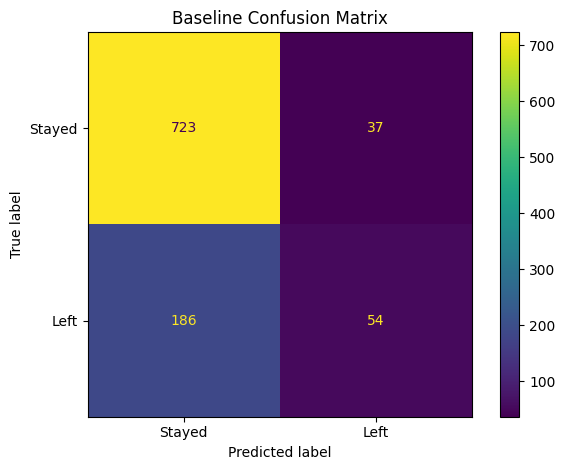

In [7]:
cm = confusion_matrix(y_test, baseline_pred)
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Left"]).plot()
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_baseline_confusion_matrix.png", dpi=150)
plt.show()

## 4. Domain-driven, polynomial, interaction, and binned features

In [8]:
X_train_eng = add_domain_features(X_train)
X_test_eng = add_domain_features(X_test)

print("Original features:", X_train.shape[1])
print("Engineered features:", X_train_eng.shape[1])
print("New features:")
print([c for c in X_train_eng.columns if c not in X_train.columns])

Original features: 27
Engineered features: 39
New features:
['CareerStability', 'RoleStability', 'ManagerStability', 'PromotionDelay', 'IncomePerWorkingYear', 'AgeSquared', 'IncomeSquared', 'DistanceSquared', 'Overtime_Satisfaction', 'Income_JobLevel', 'AgeGroup', 'DistanceGroup']


### Leakage-safe target encoding

In [9]:
department_map, global_target_mean = fit_target_encoding(X_train_eng, y_train, column="Department")
X_train_eng = apply_target_encoding(X_train_eng, department_map, global_target_mean, column="Department")
X_test_eng = apply_target_encoding(X_test_eng, department_map, global_target_mean, column="Department")

print("Training Department target encoding:")
print(pd.Series(department_map).sort_values())

Training Department target encoding:
Marketing      0.219949
Finance        0.230174
Sales          0.234824
IT             0.239063
Operations     0.239161
Engineering    0.246231
HR             0.276190
dtype: float64


<Figure size 700x400 with 0 Axes>

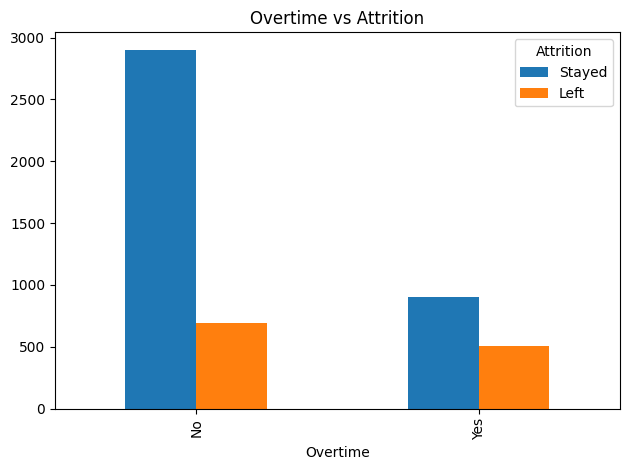

In [10]:
plt.figure(figsize=(7, 4))
pd.crosstab(X["Overtime"], y).rename(columns={0: "Stayed", 1: "Left"}).plot(kind="bar")
plt.title("Overtime vs Attrition")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_overtime_vs_attrition.png", dpi=150)
plt.show()

<Figure size 700x400 with 0 Axes>

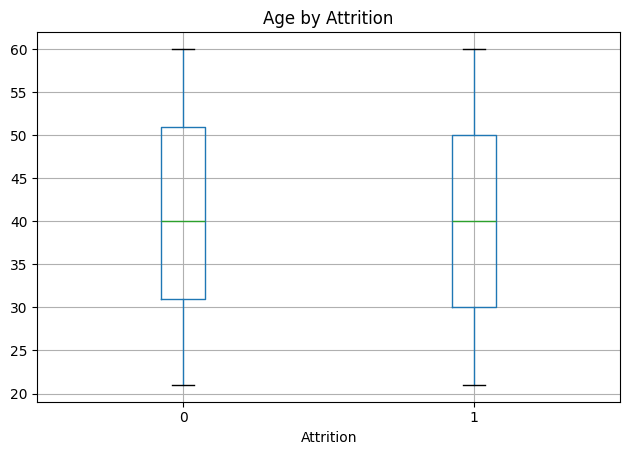

In [11]:
plt.figure(figsize=(7, 4))
df.boxplot(column="Age", by="Attrition")
plt.suptitle("")
plt.title("Age by Attrition")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_age_by_attrition.png", dpi=150)
plt.show()

## 5. Preprocess engineered features

In [12]:
preprocessor = build_preprocessor(X_train_eng)
X_train_processed = preprocessor.fit_transform(X_train_eng)
X_test_processed = preprocessor.transform(X_test_eng)
feature_names = preprocessor.get_feature_names_out()

print("Processed training matrix:", X_train_processed.shape)

Processed training matrix: (4000, 70)


## 6. Mutual Information, RFE, and L1 feature selection

In [13]:
selection = select_features(
    X_train_processed, y_train, feature_names, mi_k=25, rfe_k=15, l1_c=0.1
)

print("Mutual Information selected:", len(selection["mi_selected"]))
print("RFE selected:", len(selection["rfe_selected"]))
print("L1 selected:", len(selection["l1_selected"]))
print("Union selected:", len(selection["selected"]))

mi_table = selection["mi_scores"].head(15).rename("MI_Score").reset_index()
mi_table.columns = ["Feature", "MI_Score"]
mi_table

Mutual Information selected: 25
RFE selected: 15
L1 selected: 31
Union selected: 51


,Feature,MI_Score
0,num__DistanceSquared,0.027883
1,num__DistanceFromHome,0.022613
2,num__Overtime_Satisfaction,0.021766
3,num__YearsSincePromotion,0.016178
4,cat__Overtime_Yes,0.014753
5,cat__DistanceGroup_Very Far,0.014562
6,num__Age,0.014295
7,num__JobSatisfaction,0.013981
8,num__YearsInCurrentRole,0.013826
9,num__ManagerStability,0.013773


<Figure size 900x600 with 0 Axes>

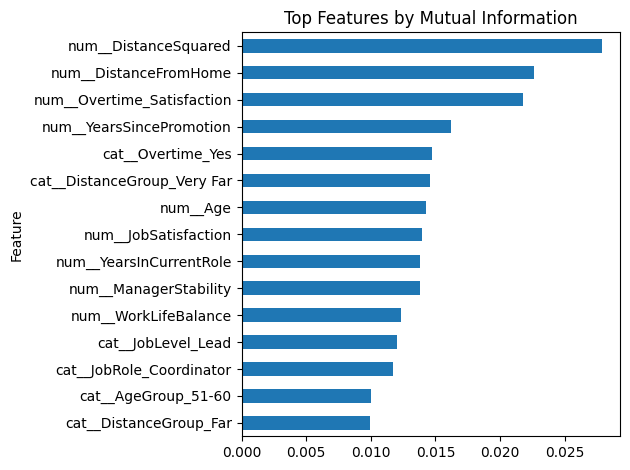

In [14]:
plt.figure(figsize=(9, 6))
mi_table.sort_values("MI_Score").plot(kind="barh", x="Feature", y="MI_Score", legend=False)
plt.title("Top Features by Mutual Information")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_mutual_information.png", dpi=150)
plt.show()

## 7. Final model using the selected feature union

In [15]:
selected = selection["selected"]
name_to_idx = {name: i for i, name in enumerate(feature_names)}
selected_idx = [name_to_idx[name] for name in selected]

final_model = LogisticRegression(max_iter=3000)
final_model.fit(X_train_processed[:, selected_idx], y_train)
final_pred = final_model.predict(X_test_processed[:, selected_idx])
final_prob = final_model.predict_proba(X_test_processed[:, selected_idx])[:, 1]
final_metrics = evaluate_classifier(y_test, final_pred, final_prob)

comparison = pd.DataFrame([baseline_metrics, final_metrics], index=["Baseline", "Engineered + Selection"])
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline,0.777,0.593407,0.225000,0.326284,0.739688
Engineered + Selection,0.778,0.597826,0.229167,0.331325,0.742083


## 8. Feature importance

In [16]:
rf_model, importance = fit_feature_importance(
    X_train_processed[:, selected_idx], y_train, np.array(selected)
)
importance.head(15).rename("Importance").to_frame()

,Importance
num__MonthlyIncome,0.053655
num__DistanceFromHome,0.052647
num__DistanceSquared,0.052012
num__Income_JobLevel,0.051209
num__IncomePerWorkingYear,0.049610
num__TrainingHours,0.046956
num__CareerStability,0.042374
num__AgeSquared,0.036994
num__Age,0.036706
num__SalaryHikePercent,0.035907


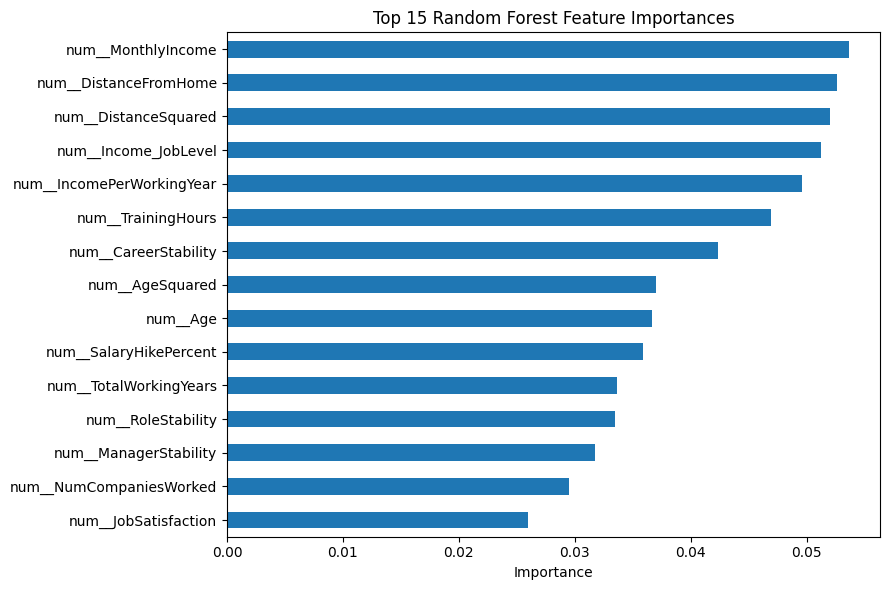

In [17]:
importance.head(15).sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_feature_importance.png", dpi=150)
plt.show()

## 9. Baseline vs final evaluation

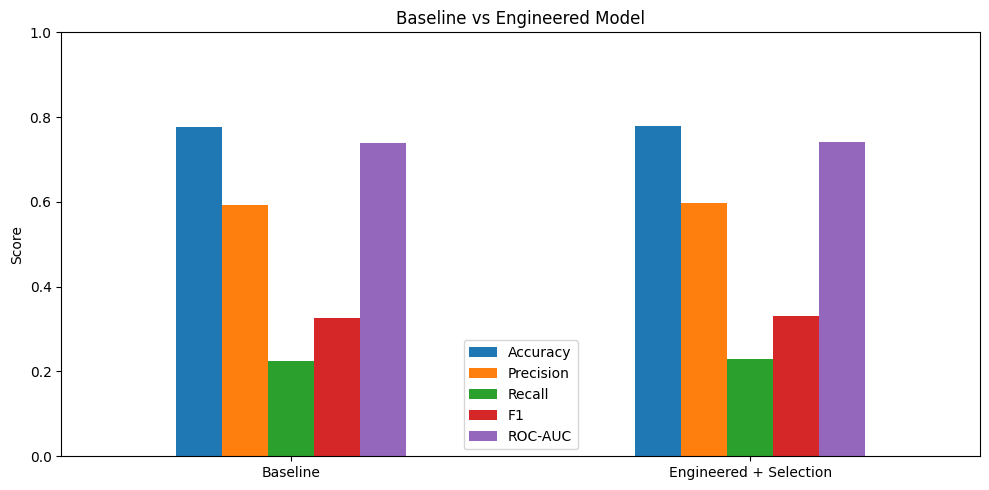

In [18]:
comparison.plot(kind="bar", figsize=(10, 5))
plt.ylim(0, 1)
plt.title("Baseline vs Engineered Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_baseline_vs_final.png", dpi=150)
plt.show()

In [19]:
print("Baseline metrics")
for key, value in baseline_metrics.items():
    print(f"{key}: {value:.3f}")

print("\nEngineered + selection metrics")
for key, value in final_metrics.items():
    print(f"{key}: {value:.3f}")

print("\nInterpretation:")
print("ROC-AUC change:", round(final_metrics["ROC-AUC"] - baseline_metrics["ROC-AUC"], 4))
print("F1 change:", round(final_metrics["F1"] - baseline_metrics["F1"], 4))

Baseline metrics
Accuracy: 0.777
Precision: 0.593
Recall: 0.225
F1: 0.326
ROC-AUC: 0.740

Engineered + selection metrics
Accuracy: 0.778
Precision: 0.598
Recall: 0.229
F1: 0.331
ROC-AUC: 0.742

Interpretation:
ROC-AUC change: 0.0024
F1 change: 0.005


## 10. Conclusion

The workflow demonstrates all requested Task 03 techniques while keeping preprocessing and target encoding leakage-safe. The engineered feature set should be judged by the evaluation results rather than by feature count alone. In this dataset, ROC-AUC improves slightly while F1 declines, so further model/threshold tuning would be appropriate before deployment.